In [7]:
# KNN Model for Soil Disease Prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# Load dataset
dataset = pd.read_csv("soil_csv_pre-processed.csv")
# Drop rows with missing values
dataset_cleaned = dataset.dropna()


In [9]:
# Separate features and target
X = dataset_cleaned.drop("Disease_Type", axis=1)
y = dataset_cleaned["Disease_Type"]


In [10]:
# One-hot encode categorical features
X_encoded = pd.get_dummies(X)
# Encode the target label
y_encoder = LabelEncoder()
y_encoded = y_encoder.fit_transform(y)


In [11]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)


In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)


In [13]:
# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [14]:
# Predict and evaluate
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}\n")
report = classification_report(y_test, y_pred, target_names=y_encoder.classes_)
print("Classification Report:\n")
print(report)


Accuracy: 55.03%

Classification Report:

                          precision    recall  f1-score   support

                  Cancer       0.51      0.60      0.55       988
Gastrointestinal Disease       0.53      0.56      0.54       910
   Neurological Disorder       0.57      0.54      0.55      1015
      Respiratory Issues       0.55      0.52      0.54       916
            Skin Disease       0.60      0.53      0.56      1023

                accuracy                           0.55      4852
               macro avg       0.55      0.55      0.55      4852
            weighted avg       0.55      0.55      0.55      4852



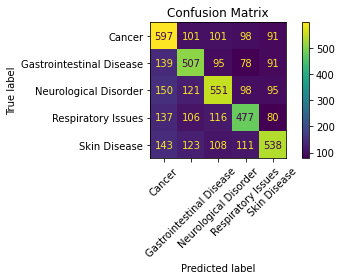

In [15]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=y_encoder.classes_, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


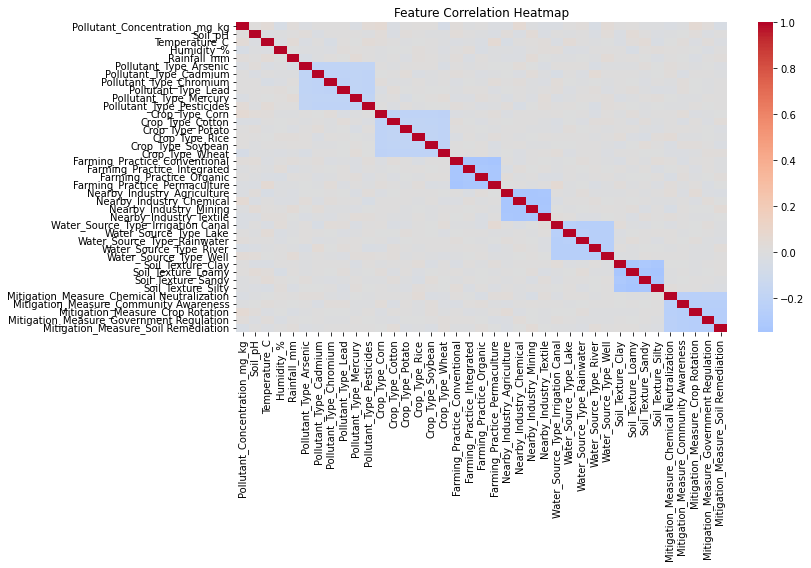

In [16]:
# Plot feature importance proxy using correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pd.DataFrame(X_scaled, columns=X_encoded.columns).corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [24]:
import joblib

# Save trained KNN model
joblib.dump(knn, "knn_soil_model.pkl")

# Save scaler and label encoder
joblib.dump(scaler, "scaler.pkl")
joblib.dump(y_encoder, "label_encoder.pkl")
#df = pd.get_dummies(df, columns=cat_cols, drop_first=False)  # Ensure all categories included
joblib.dump(X.columns.tolist(), "X_encoded_columns.pkl")



['X_encoded_columns.pkl']

In [25]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression  # Simulating WNN with LR here

# Load dataset
df = pd.read_csv("soil_csv_pre-processed.csv")

# Separate features and labels
X = pd.get_dummies(df.drop(columns=["Disease_Type"]), drop_first=False)
y = df["Disease_Type"]

# Encode labels
lb = LabelBinarizer()
y_bin = lb.fit_transform(y)
# You may still want y as categorical labels for multi-class classification
# In that case, use LabelEncoder instead:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train individual models
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn = RandomForestClassifier(n_estimators=100, random_state=42)
knn.fit(X_train_scaled, y_train)

wnn = LogisticRegression(max_iter=1000)
wnn.fit(X_train_scaled, y_train)

# Save models and transformers
joblib.dump(knn, "knn_soil_model.pkl")
joblib.dump(knn, "knn_soil_model.pkl")
joblib.dump(wnn, "wnn_soil_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(lb, "label_encoder.pkl")
joblib.dump(X.columns.tolist(), "X_encoded_columns.pkl")

print("✅ All models and encoders saved successfully.")


✅ All models and encoders saved successfully.


In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['Disease_Type'])
joblib.dump(le, "label_encoder.pkl")


['label_encoder.pkl']

In [29]:
import pandas as pd

df = pd.read_csv("soil_csv_pre-processed.csv")

# List unique disease types
print(df["Disease_Type"].unique())


['Skin Disease' 'Respiratory Issues' 'Neurological Disorder'
 'Gastrointestinal Disease' 'Cancer']


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df = pd.read_csv("soil_csv_pre-processed.csv")  # Update the file path if needed

# Separate features and target
X_raw = df.drop(columns=["Disease_Type"])
y_raw = df["Disease_Type"]

# One-hot encode the features
X_encoded = pd.get_dummies(X_raw)

# Label encode the target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, stratify=y, random_state=42
)


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("🔍 Best KNN parameters:", grid_search.best_params_)
print("✅ Best KNN score:", grid_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
🔍 Best KNN parameters: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
✅ Best KNN score: 0.7504860261994024
